In [2]:
import copy, math, random, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt, os
import pandas as pd
from typing import Dict, List
import copy, math, os, pickle, random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


# ============================================================
# 0. SEED
# ============================================================
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

# ============================================================
# 1. SAMPLER
#    4 players, 3 demand units, 2 supply units each.
#
#    Case "pab_should_win":   costs ~ U(0, 1)
#      High heterogeneity -> large infra-marginal rents under PAC.
#      The cheapest plant (cost ~0) is paid the clearing price (~0.8)
#      under PAC, collecting a huge rent. PAB removes that rent -> cheaper.
#
#    Case "uniform_should_win":  costs ~ U(0.4, 1.0)
#      Concentrated costs near the capacity limit.
#      All players shade toward the expected clearing price,
#      so bid-shading under PAB inflates prices above PAC.
# ============================================================
class ProcurementSampler:
    def __init__(self, scenario_name):
        self.scenario_name = scenario_name
        self.n_players    = 4
        self.demand_units = 3
        self.supply_cap   = 2  # max units per player

        if scenario_name == "pab_should_win":
            self.cost_low, self.cost_high = 0.0, 1.0
        elif scenario_name == "uniform_should_win":
            self.cost_low, self.cost_high = 0.4, 0.6
        else:
            raise ValueError(f"Unknown scenario: {scenario_name}")

    def sample(self, batch_size):
        c = torch.rand(batch_size, self.n_players, 1) * (self.cost_high - self.cost_low) + self.cost_low
        return c, c.clone()

# ============================================================
# 2. BNE ANALYTICAL FORMULA
#    beta(phi) = 3*(phi+1)^2 / (4*(phi+2))
#    Valid for the PAB equilibrium on cost support [0,1].
# ============================================================
def bne_analytical(phi):
    return 3*(phi+1)**2 / (4*(phi+2))

# ============================================================
# 3. BIDDER NET  (bid = cost + nonneg markup)
# ============================================================
class BidderNet(nn.Module):
    def __init__(self, hidden=10):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, hidden), nn.SELU(),
            nn.Linear(hidden, hidden), nn.SELU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return x + torch.relu(self.layers(x))

# ============================================================
# 4. PRETRAIN
# ============================================================
def pretrain_truthful(policies, sampler, device, steps=200, batch_size=4096, lr=1e-2):
    optims = [torch.optim.SGD(p.parameters(), lr=lr) for p in policies]
    print("\n>>> Pretraining truthful bidding (bid = cost)...")
    for step in range(steps):
        c, o = sampler.sample(batch_size)
        c, o = c.to(device), o.to(device)
        loss = 0.0
        for i, pol in enumerate(policies):
            optims[i].zero_grad()
            l = ((pol(o[:,i]) - c[:,i])**2).mean()
            l.backward()
            optims[i].step()
            loss += l.item()
        if step % 50 == 0 or step == steps-1:
            print(f"  step {step:4d}/{steps} | loss={loss/len(policies):.8f}")

In [3]:
# ============================================================
# 5. MULTI-UNIT CLEARING  (supply_cap units per player)
#
#   Sort players by bid (ascending = cheapest first).
#   Allocate up to supply_cap units per player until demand met.
#   Clearing price = bid of the marginal unit (last unit accepted).
#
#   PAC:  all accepted players paid clearing_price per unit
#   PAB:  each accepted player paid own bid per unit
# ============================================================
def procurement_outcome(bids, costs, demand_units, supply_cap, pricing):
    """
    bids, costs: (B, N)
    Returns: accepted_mask (B,N bool), payments (B,N), profits (B,N),
             buyer_cost (B,), clearing_bid (B,), units_sold (B,N)
    """
    B, N = bids.shape
    device = bids.device

    # Sort by bid ascending
    sorted_bids, sort_idx = bids.sort(dim=1)          # (B, N)
    sorted_costs = costs.gather(1, sort_idx)

    # Greedy unit allocation
    remaining = torch.full((B,), float(demand_units), device=device)
    units_sorted = torch.zeros(B, N, device=device)
    for j in range(N):
        give = torch.clamp(remaining, 0.0, float(supply_cap))
        units_sorted[:, j] = give
        remaining = remaining - give

    # Map back to original order
    units_sold = torch.zeros(B, N, device=device)
    units_sold.scatter_(1, sort_idx, units_sorted)

    accepted_mask = units_sold > 0   # (B, N) bool

    # Clearing price = highest accepted bid (marginal unit)
    LARGE = 1e9
    masked = bids.clone()
    masked[~accepted_mask] = -LARGE
    clearing_bid = masked.max(dim=1).values  # (B,)

    # Payments
    if pricing == "uniform":
        pay_per_unit = clearing_bid.unsqueeze(1).expand(B, N)
    else:  # pay_as_bid
        pay_per_unit = bids

    payments = pay_per_unit * units_sold
    profits  = payments - costs * units_sold
    buyer_cost = payments.sum(dim=1)

    return accepted_mask, payments, profits, buyer_cost, clearing_bid, units_sold

# ============================================================
# 6. EVALUATION
# ============================================================
@torch.no_grad()
def evaluate_policies(policies, sampler, device, pricing, eval_batch_size=8192):
    N = sampler.n_players
    c, o = sampler.sample(eval_batch_size)
    c, o = c.to(device), o.to(device)

    bids = torch.cat([policies[i](o[:,i]) for i in range(N)], dim=1)
    c2   = c.squeeze(-1)

    accepted_mask, payments, profits, buyer_cost, clearing, units_sold = \
        procurement_outcome(bids, c2, sampler.demand_units, sampler.supply_cap, pricing)

    acc_f  = accepted_mask.float()
    n_acc  = acc_f.sum().clamp(min=1)

    # Bid curve on cost support grid
    grid_c = torch.linspace(sampler.cost_low, sampler.cost_high, 200, device=device).unsqueeze(1)
    curves = [policies[i](grid_c).squeeze().cpu().numpy() for i in range(N)]
    curves = np.array(curves)

    return {
        "avg_bid":             bids.mean().item(),
        "avg_markup":          (bids - c2).mean().item(),
        "avg_accepted_bid":    (bids*acc_f).sum().item() / n_acc.item(),
        "avg_payment":         payments.sum().item() / n_acc.item(),
        "buyer_cost":          buyer_cost.mean().item(),
        "supplier_profit":     profits.sum(dim=1).mean().item(),
        "clearing_bid":        clearing.mean().item(),
        "curves_all":          curves,
        "curve_mean":          curves.mean(axis=0),
        "grid":                grid_c.squeeze().cpu().numpy(),
    }

# ============================================================
# 7. NPGA PSEUDOGRADIENT
# ============================================================
def flatten_params(model):
    return torch.cat([p.data.flatten() for p in model.parameters()])

def load_flat_params(model, theta):
    off = 0
    for p in model.parameters():
        n = p.numel(); p.data.copy_(theta[off:off+n].view_as(p)); off += n

def npga_gradient(player_idx, policies, sampler, device, pricing, batch_size, pop, sigma):
    pol    = policies[player_idx]
    params = list(pol.parameters())
    flat   = flatten_params(pol)
    d      = flat.numel()
    N      = sampler.n_players

    c, o = sampler.sample(batch_size)
    c, o = c.to(device), o.to(device)
    c2   = c.squeeze(-1)

    # Baseline
    with torch.no_grad():
        bids_b = torch.cat([policies[i](o[:,i]) for i in range(N)], dim=1)
        _, _, prof_b, _, _, _ = procurement_outcome(bids_b, c2,
            sampler.demand_units, sampler.supply_cap, pricing)
        baseline = prof_b[:, player_idx].mean().item()

    # Perturbations
    eps   = torch.randn(pop, d, device=device) * sigma
    fits  = torch.zeros(pop, device=device)

    for p_idx in range(pop):
        # Apply perturbation
        off = 0
        for param in params:
            n = param.numel()
            param.data.add_(eps[p_idx, off:off+n].view_as(param))
            off += n

        with torch.no_grad():
            bids_p = torch.cat([policies[i](o[:,i]) for i in range(N)], dim=1)
            _, _, prof_p, _, _, _ = procurement_outcome(bids_p, c2,
                sampler.demand_units, sampler.supply_cap, pricing)
            fits[p_idx] = prof_p[:, player_idx].mean() - baseline

        # Undo perturbation
        off = 0
        for param in params:
            n = param.numel()
            param.data.sub_(eps[p_idx, off:off+n].view_as(param))
            off += n

    grad_flat = (fits.unsqueeze(1) * eps).sum(0) / (sigma**2 * pop)
    grads, off = [], 0
    for param in params:
        n = param.numel()
        grads.append(grad_flat[off:off+n].view_as(param))
        off += n
    return grads

# ============================================================
# 8. TRAINING LOOP
# ============================================================
def train_npga(scenario_name, pricing, n_epochs=400, pretrain_iters=200,
               batch_size=4096, pop=32, lr=3e-3, sigma=1e-2, hidden=10,
               eval_frequency=50, n_runs=3, eval_batch_size=8192, seed_base=42):

    device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n>>> Device: {device} | Scenario: {scenario_name} | Pricing: {pricing}")

    all_results = []
    for run in range(n_runs):
        set_seed(seed_base + run*100)
        sampler = ProcurementSampler(scenario_name)
        N = sampler.n_players

        print(f"\n{'='*60}")
        print(f"RUN {run+1}/{n_runs} | N={N} | demand={sampler.demand_units} | cap={sampler.supply_cap} | costs~U[{sampler.cost_low},{sampler.cost_high}]")
        print(f"{'='*60}")

        policies = [BidderNet(hidden).to(device) for _ in range(N)]
        optims   = [torch.optim.Adam(p.parameters(), lr=lr) for p in policies]
        pretrain_truthful(policies, sampler, device, pretrain_iters, batch_size)

        res = {k: [] for k in ["epoch","buyer_cost","supplier_profit","avg_bid",
                                "avg_markup","avg_accepted_bid","avg_payment",
                                "clearing_bid","grad_norm","curve_mean","curves_all","grid"]}

        for epoch in range(n_epochs):
            grad_norms = []
            for i in range(N):
                grads = npga_gradient(i, policies, sampler, device,
                                      pricing, batch_size, pop, sigma)
                optims[i].zero_grad()
                for param, g in zip(policies[i].parameters(), grads):
                    param.grad = -g   # Adam minimises, we want to maximise
                nn.utils.clip_grad_norm_(policies[i].parameters(), 1.0)
                optims[i].step()
                grad_norms.append(torch.cat([g.view(-1) for g in grads]).norm().item())

            if epoch % eval_frequency == 0 or epoch == n_epochs-1:
                ev = evaluate_policies(policies, sampler, device, pricing, eval_batch_size)
                res["epoch"].append(epoch)
                for k in ["buyer_cost","supplier_profit","avg_bid","avg_markup",
                          "avg_accepted_bid","avg_payment","clearing_bid"]:
                    res[k].append(ev[k])
                res["grad_norm"].append(float(np.mean(grad_norms)))
                res["curve_mean"].append(ev["curve_mean"])
                res["curves_all"].append(ev["curves_all"])
                res["grid"].append(ev["grid"])
                print(f"[{epoch:4d}] BuyerCost={ev['buyer_cost']:.4f} | "
                      f"AvgBid={ev['avg_bid']:.4f} | "
                      f"Clear={ev['clearing_bid']:.4f} | "
                      f"Markup={ev['avg_markup']:.4f} | "
                      f"GradNorm={np.mean(grad_norms):.2e}")
        all_results.append(res)

    print("\n>>> Training finished.")
    return all_results

In [4]:
# ============================================================
# 9. COMPARISON
# ============================================================
def mean_path(results_list, metric):
    arr = np.array([r[metric] for r in results_list], dtype=float)
    return arr.mean(0), arr.std(0)

def compare_pricing(res_u, res_p, scenario_name):
    cu = np.mean([r["buyer_cost"][-1] for r in res_u])
    cp = np.mean([r["buyer_cost"][-1] for r in res_p])
    winner = "uniform" if cu < cp else "pay_as_bid"
    print(f"\n{'#'*70}\nSCENARIO: {scenario_name}")
    print(f"Buyer cost | uniform    = {cu:.6f}")
    print(f"Buyer cost | pay_as_bid = {cp:.6f}")
    print(f"WINNER: {winner}\n{'#'*70}")
    return winner

# ============================================================
# 10. PLOTTING  (3 panels: expenditure | avg bid | bid function + BNE)
# ============================================================
def paper_style():
    plt.rcParams.update({
        "figure.dpi": 140, "savefig.dpi": 300,
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "legend.fontsize": 10, "lines.linewidth": 2.0,
        "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False,
    })

def plot_with_bne(res_uniform, res_pab, title_prefix,
                  show_bne=True, save_dir=None):
    """
    3-panel figure:
      (a) Buyer expenditure over training
      (b) Average bid over training
      (c) Final equilibrium bid function  +  analytical BNE
    """
    paper_style()
    uc, pc = "steelblue", "firebrick"
    bne_c  = "black"

    epochs  = np.array(res_uniform[0]["epoch"])

    u_exp_m, u_exp_s = mean_path(res_uniform, "buyer_cost")
    p_exp_m, p_exp_s = mean_path(res_pab,     "buyer_cost")
    u_bid_m, u_bid_s = mean_path(res_uniform, "avg_bid")
    p_bid_m, p_bid_s = mean_path(res_pab,     "avg_bid")

    # Final bid curve across all runs
    cu = np.array([r["curve_mean"][-1] for r in res_uniform])
    cp = np.array([r["curve_mean"][-1] for r in res_pab])
    grid = res_uniform[0]["grid"][-1]   # cost grid from last eval

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # --- (a) Buyer expenditure ---
    ax = axes[0]
    ax.plot(epochs, u_exp_m, label="Uniform",        color=uc)
    ax.fill_between(epochs, u_exp_m-u_exp_s, u_exp_m+u_exp_s, alpha=.2, color=uc)
    ax.plot(epochs, p_exp_m, label="Discriminatory", color=pc)
    ax.fill_between(epochs, p_exp_m-p_exp_s, p_exp_m+p_exp_s, alpha=.2, color=pc)
    ax.set_title("(a) Auctioneer's expenditure")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Auctioneer's expenditure")
    ax.legend()

    # --- (b) Average bid ---
    ax = axes[1]
    ax.plot(epochs, u_bid_m, label="Uniform",        color=uc)
    ax.fill_between(epochs, u_bid_m-u_bid_s, u_bid_m+u_bid_s, alpha=.2, color=uc)
    ax.plot(epochs, p_bid_m, label="Discriminatory", color=pc)
    ax.fill_between(epochs, p_bid_m-p_bid_s, p_bid_m+p_bid_s, alpha=.2, color=pc)
    ax.set_title("(b) Average bid")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Mean bid")
    ax.legend()

    # --- (c) Bid function + BNE ---
    ax = axes[2]
    ax.plot(grid, cu.mean(0), label="Uniform (learned)",        color=uc)
    ax.fill_between(grid, cu.mean(0)-cu.std(0), cu.mean(0)+cu.std(0), alpha=.2, color=uc)
    ax.plot(grid, cp.mean(0), label="Discriminatory (learned)", color=pc)
    ax.fill_between(grid, cp.mean(0)-cp.std(0), cp.mean(0)+cp.std(0), alpha=.2, color=pc)
    ax.plot(grid, grid, "k--", lw=1, label="Truthful: $b=\\phi$")
    if show_bne:
        bne_vals = bne_analytical(grid)
        ax.plot(grid, bne_vals, color=bne_c, lw=2, ls="-.",
                label=r"BNE: $\beta(\phi)=\frac{3(\phi+1)^2}{4(\phi+2)}$")
    ax.set_title("(c) Equilibrium bid function")
    ax.set_xlabel("Marginal cost $\\phi$"); ax.set_ylabel("Bid $b(\\phi)$")
    ax.legend(fontsize=8)

    fig.suptitle(title_prefix, y=1.02, fontsize=13)
    plt.tight_layout()

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        safe = title_prefix.lower().replace(" ","_").replace(":","").replace("(","").replace(")","")
        fig.savefig(os.path.join(save_dir, f"{safe}.pdf"), bbox_inches="tight")
        fig.savefig(os.path.join(save_dir, f"{safe}.png"), bbox_inches="tight")
    plt.show()

In [ ]:
# ============================================================
# 11. RUN
# ============================================================
common = dict(
        n_epochs=600, pretrain_iters=200,
        batch_size=4096, pop=64, lr=3e-3, sigma=0.02,
        hidden=10, eval_frequency=50, n_runs=25, eval_batch_size=8192,
    )
# Case 1: U(0, 1) — PAB should win
print("\n" + "="*60 + "\nCASE 1: U(0, 1)  →  PAB expected to win\n" + "="*60)
res_u1 = train_npga("pab_should_win", "uniform",    **common)
res_p1 = train_npga("pab_should_win", "pay_as_bid", **common)
compare_pricing(res_u1, res_p1, "pab_should_win [U(0, 1)]")
plot_with_bne(
        res_u1, res_p1,
        title_prefix="Case 1: Uniform pricing cheaper",
        show_bne=False,   # BNE formula is for U(0,1), not applicable here
        save_dir="simulationPABvsPAC_v3"
    )


CASE 2: U(0.4, 0.6)  →  Uniform expected to win

>>> Device: cuda | Scenario: uniform_should_win | Pricing: uniform

RUN 1/25 | N=4 | demand=3 | cap=2 | costs~U[0.4,0.6]

>>> Pretraining truthful bidding (bid = cost)...
  step    0/200 | loss=0.00000000
  step   50/200 | loss=0.00000000
  step  100/200 | loss=0.00000000
  step  150/200 | loss=0.00000000
  step  199/200 | loss=0.00000000
[   0] BuyerCost=1.4404 | AvgBid=0.5002 | Clear=0.4801 | Markup=0.0000 | GradNorm=0.00e+00
[  50] BuyerCost=1.4419 | AvgBid=0.5002 | Clear=0.4806 | Markup=0.0000 | GradNorm=0.00e+00
[ 100] BuyerCost=1.4394 | AvgBid=0.4999 | Clear=0.4798 | Markup=0.0000 | GradNorm=0.00e+00
[ 150] BuyerCost=1.4420 | AvgBid=0.5021 | Clear=0.4807 | Markup=0.0020 | GradNorm=2.60e-02
[ 200] BuyerCost=1.4464 | AvgBid=0.5071 | Clear=0.4821 | Markup=0.0075 | GradNorm=2.38e-02
[ 250] BuyerCost=1.4487 | AvgBid=0.5064 | Clear=0.4829 | Markup=0.0073 | GradNorm=2.93e-02
[ 300] BuyerCost=1.4416 | AvgBid=0.5008 | Clear=0.4805 | Markup

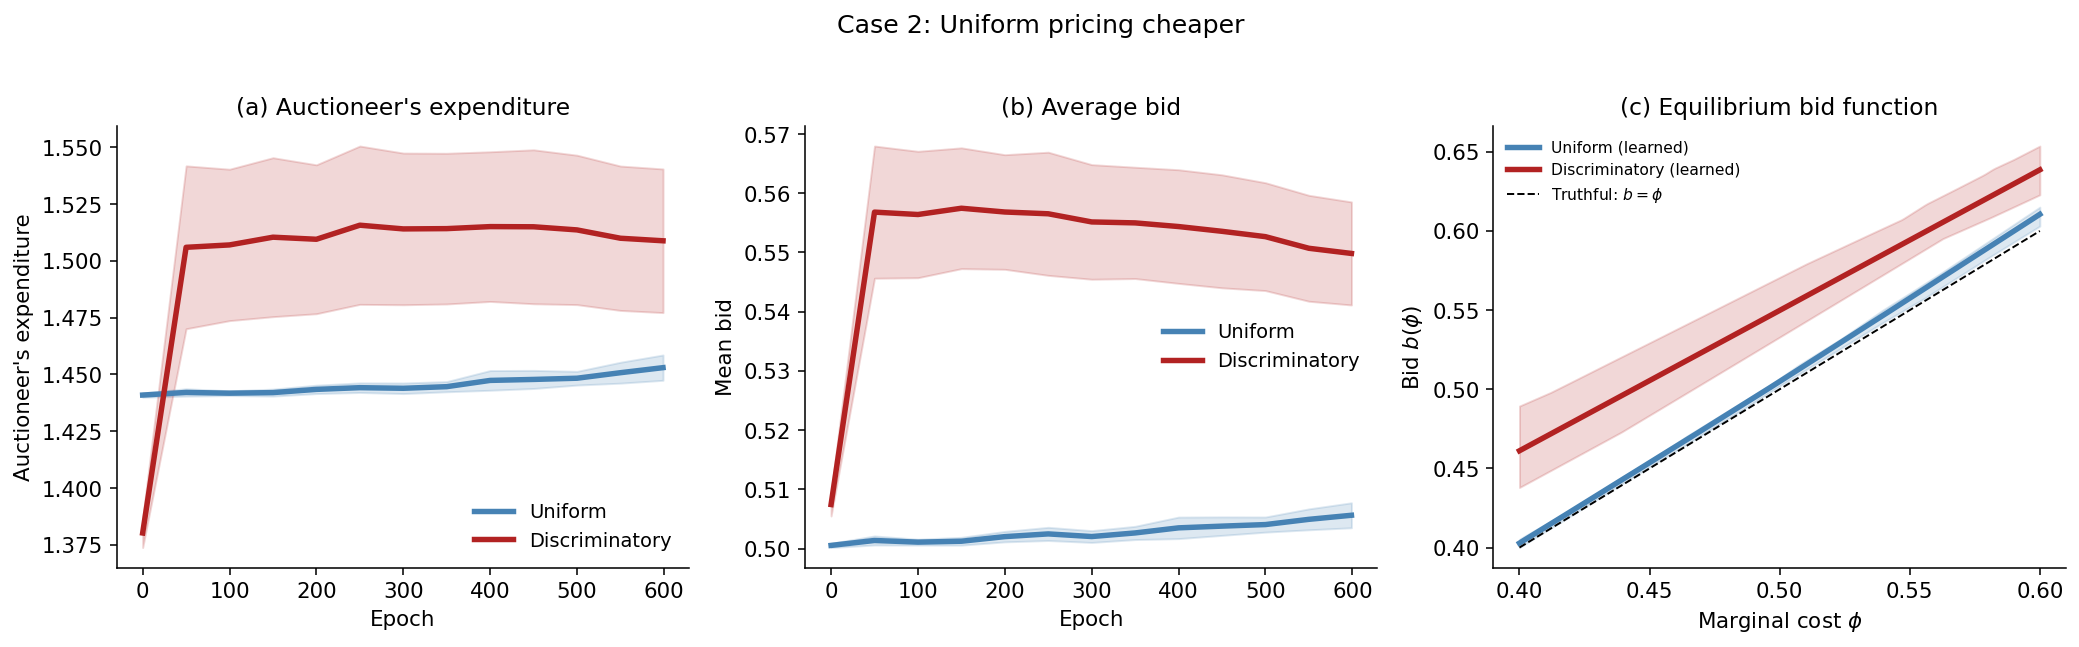

In [22]:
common = dict(
        n_epochs=600, pretrain_iters=200,
        batch_size=4096, pop=64, lr=3e-3, sigma=0.02,
        hidden=10, eval_frequency=50, n_runs=25, eval_batch_size=8192,
    )
# Case 2: U(0, 10) — Uniform should win
print("\n" + "="*60 + "\nCASE 2: U(0.4, 0.6)  →  Uniform expected to win\n" + "="*60)
res_u2 = train_npga("uniform_should_win", "uniform",    **common)
res_p2 = train_npga("uniform_should_win", "pay_as_bid", **common)
compare_pricing(res_u2, res_p2, "uniform_should_win [U(0.4, 0.6)]")
plot_with_bne(
        res_u2, res_p2,
        title_prefix="Case 2: Uniform pricing cheaper",
        show_bne=False,   # BNE formula is for U(0,1), not applicable here
        save_dir="simulationPABvsPAC_v3"
    )

In [23]:
# ============================================================
# 9. EXPORT HELPERS
# ============================================================
def final_metric_mean(results_list, metric):
    vals = [float(r[metric][-1]) for r in results_list]
    return float(np.mean(vals))

def build_summary_table(results_dict):
    rows = []
    for name, res in results_dict.items():
        rows.append(
            {
                "result_name": name,
                "buyer_cost_final_mean": final_metric_mean(res, "buyer_cost"),
                "avg_bid_final_mean": final_metric_mean(res, "avg_bid"),
                "avg_markup_final_mean": final_metric_mean(res, "avg_markup"),
                "clearing_bid_final_mean": final_metric_mean(res, "clearing_bid"),
                "supplier_profit_final_mean": final_metric_mean(res, "supplier_profit"),
                "n_runs": len(res),
            }
        )
    return pd.DataFrame(rows)


def export_results_bundle(results_dict, export_dir="simulationPABvsPAC_vfinal/exports"):
    export_path = Path(export_dir)
    export_path.mkdir(parents=True, exist_ok=True)

    for name, obj in results_dict.items():
        with open(export_path / f"{name}.pkl", "wb") as f:
            pickle.dump(obj, f)

    with open(export_path / "all_results.pkl", "wb") as f:
        pickle.dump(results_dict, f)

    summary = build_summary_table(results_dict)
    summary.to_csv(export_path / "final_summary.csv", index=False)

    print(f"\nSaved exports in: {export_path.resolve()}")
    for name in results_dict:
        print(f"  - {name}.pkl")
    print("  - all_results.pkl")
    print("  - final_summary.csv")

    return summary

In [29]:
# ============================================================
# 13. EXPORT RESULTS
#    This saves the objects you asked for:
#      res_u1, res_p1, res_u2, res_p2
# ============================================================
results_dict = {
    "res_u1": res_u1,
    "res_p1": res_p1,
    "res_u2": res_u2,
    "res_p2": res_p2,
}

summary_df = export_results_bundle(
    results_dict,
    export_dir="simulationPABvsPACmultiunituniform",
)
summary_df


Saved exports in: C:\Users\HP\Documents\GitHub\TesisPEG\NPGAVF\simulationPABvsPACmultiunituniform
  - res_u1.pkl
  - res_p1.pkl
  - res_u2.pkl
  - res_p2.pkl
  - all_results.pkl
  - final_summary.csv


,result_name,buyer_cost_final_mean,avg_bid_final_mean,avg_markup_final_mean,clearing_bid_final_mean,supplier_profit_final_mean,n_runs
0,res_u1,1.513435,0.602649,0.102689,0.504478,0.702911,25
1,res_p1,1.403844,0.639172,0.139213,0.574769,0.574419,25
2,res_u2,1.453011,0.505617,0.005634,0.484337,0.091784,25
3,res_p2,1.508827,0.549831,0.049848,0.532564,0.133235,25


## Simulaciones

In [12]:
def plot_with_bne(res_uniform, res_pab, title_prefix,
                  show_bne=True, save_dir=None):
    """
    3-panel figure:
      (a) Auctioneer expenditure over training
      (b) Average bid over training
      (c) Final equilibrium bid function + analytical BNE

    Visual style:
      - Panels (a) and (b): individual simulation paths as semi-transparent lines
        plus bold mean path
      - Panel (c): mean bid curve plus interquartile band
    """
    paper_style()
    uc, pc = "steelblue", "firebrick"
    bne_c = "black"

    epochs = np.array(res_uniform[0]["epoch"])

    # Final bid curves across runs
    cu = np.array([r["curve_mean"][-1] for r in res_uniform])  # shape: n_runs x n_grid
    cp = np.array([r["curve_mean"][-1] for r in res_pab])      # shape: n_runs x n_grid
    grid = res_uniform[0]["grid"][-1]

    def plot_runs_and_mean(ax, results, key, color, label):
        arr = np.array([r[key] for r in results])  # shape: n_runs x T

        # individual runs: stronger color
        for i in range(arr.shape[0]):
            ax.plot(epochs, arr[i], color=color, alpha=0.28, lw=1.2)

        # mean path
        ax.plot(epochs, arr.mean(axis=0), color=color, lw=2.8, label=label)

    def mean_and_band(arr, lower=25, upper=75):
        mean = arr.mean(axis=0)
        lo = np.percentile(arr, lower, axis=0)
        hi = np.percentile(arr, upper, axis=0)
        return mean, lo, hi

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # --- (a) Auctioneer expenditure ---
    ax = axes[0]
    plot_runs_and_mean(ax, res_uniform, "buyer_cost", uc, "Uniform")
    plot_runs_and_mean(ax, res_pab, "buyer_cost", pc, "Discriminatory")
    ax.set_title("(a) Auctioneer's expenditure")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Auctioneer's expenditure")
    ax.legend()

    # --- (b) Average bid ---
    ax = axes[1]
    plot_runs_and_mean(ax, res_uniform, "avg_bid", uc, "Uniform")
    plot_runs_and_mean(ax, res_pab, "avg_bid", pc, "Discriminatory")
    ax.set_title("(b) Average bid")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean bid")
    ax.legend()

    # --- (c) Bid function + BNE ---
    ax = axes[2]

    u_mean, u_lo, u_hi = mean_and_band(cu, 25, 75)
    p_mean, p_lo, p_hi = mean_and_band(cp, 25, 75)

    ax.plot(grid, u_mean, label="Uniform (learned)", color=uc, lw=2.8)
    ax.fill_between(grid, u_lo, u_hi, alpha=0.18, color=uc)

    ax.plot(grid, p_mean, label="Discriminatory (learned)", color=pc, lw=2.8)
    ax.fill_between(grid, p_lo, p_hi, alpha=0.18, color=pc)

    ax.plot(grid, grid, "k--", lw=1, label="Truthful: $b=\\phi$")

    if show_bne:
        bne_vals = bne_analytical(grid)
        ax.plot(
            grid, bne_vals,
            color=bne_c, lw=2, ls="-.",
            label=r"BNE: $\beta(\phi)=\frac{3(\phi+1)^2}{4(\phi+2)}$"
        )

    ax.set_title("(c) Equilibrium bid function")
    ax.set_xlabel("Marginal cost $\\phi$")
    ax.set_ylabel("Bid $b(\\phi)$")
    ax.legend(fontsize=8)

    fig.suptitle(title_prefix, y=1.02, fontsize=13)
    plt.tight_layout()

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        safe = (
            title_prefix.lower()
            .replace(" ", "_")
            .replace(":", "")
            .replace("(", "")
            .replace(")", "")
        )
        fig.savefig(os.path.join(save_dir, f"{safe}.pdf"), bbox_inches="tight")
        fig.savefig(os.path.join(save_dir, f"{safe}.png"), bbox_inches="tight")

    plt.show()

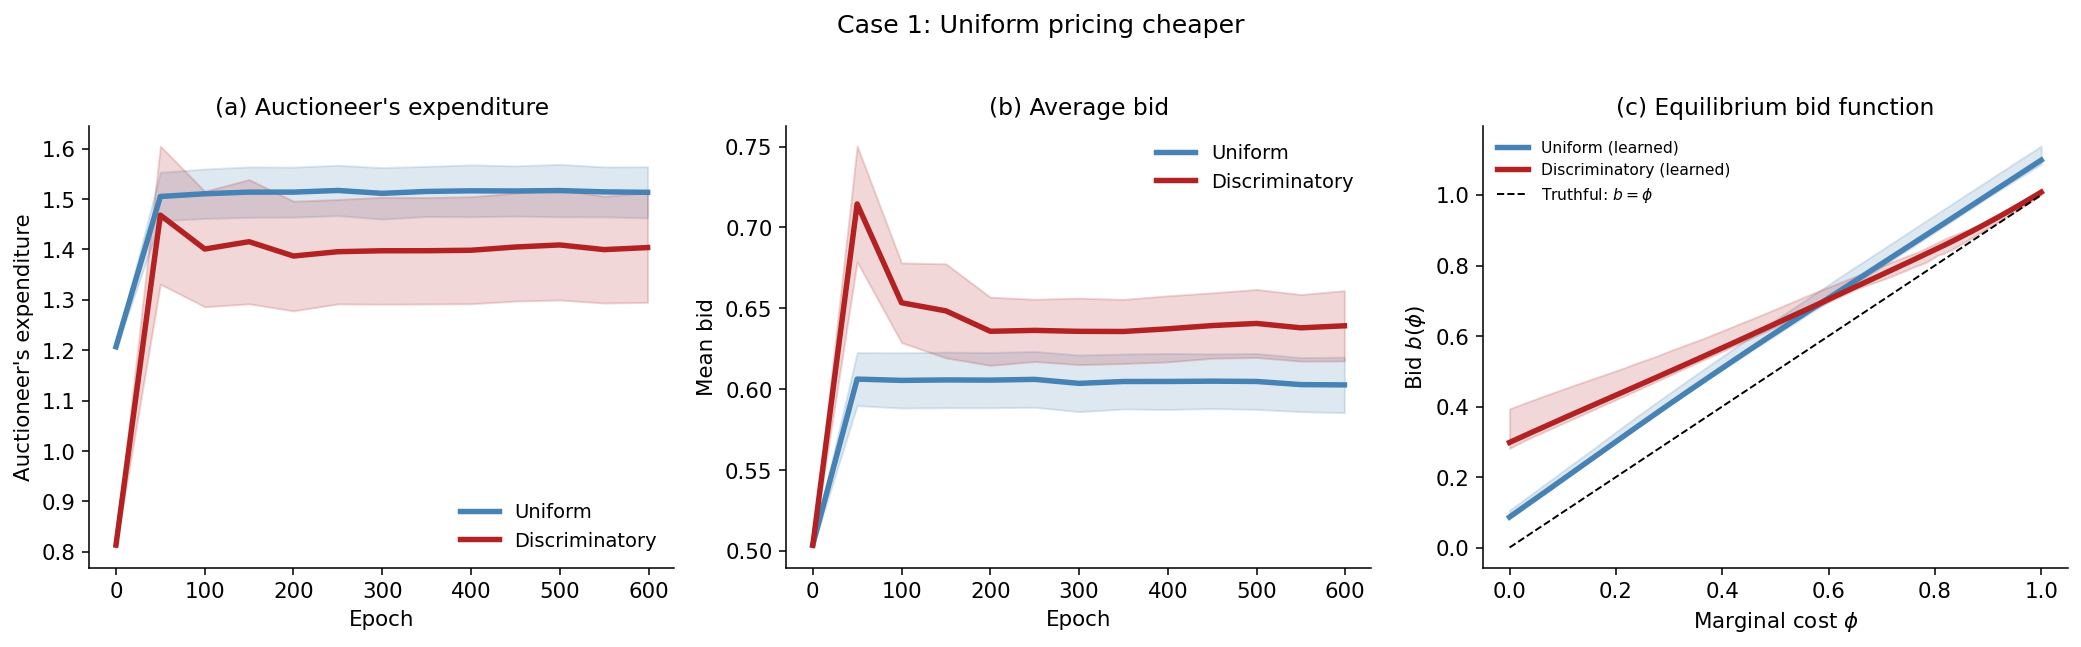

In [30]:
plot_with_bne(
        res_u1, res_p1,
        title_prefix="Case 1: Uniform pricing cheaper",
        show_bne=False,   # BNE formula is for U(0,1), not applicable here
        save_dir="simulationPABvsPACmultiunituniform"
    )

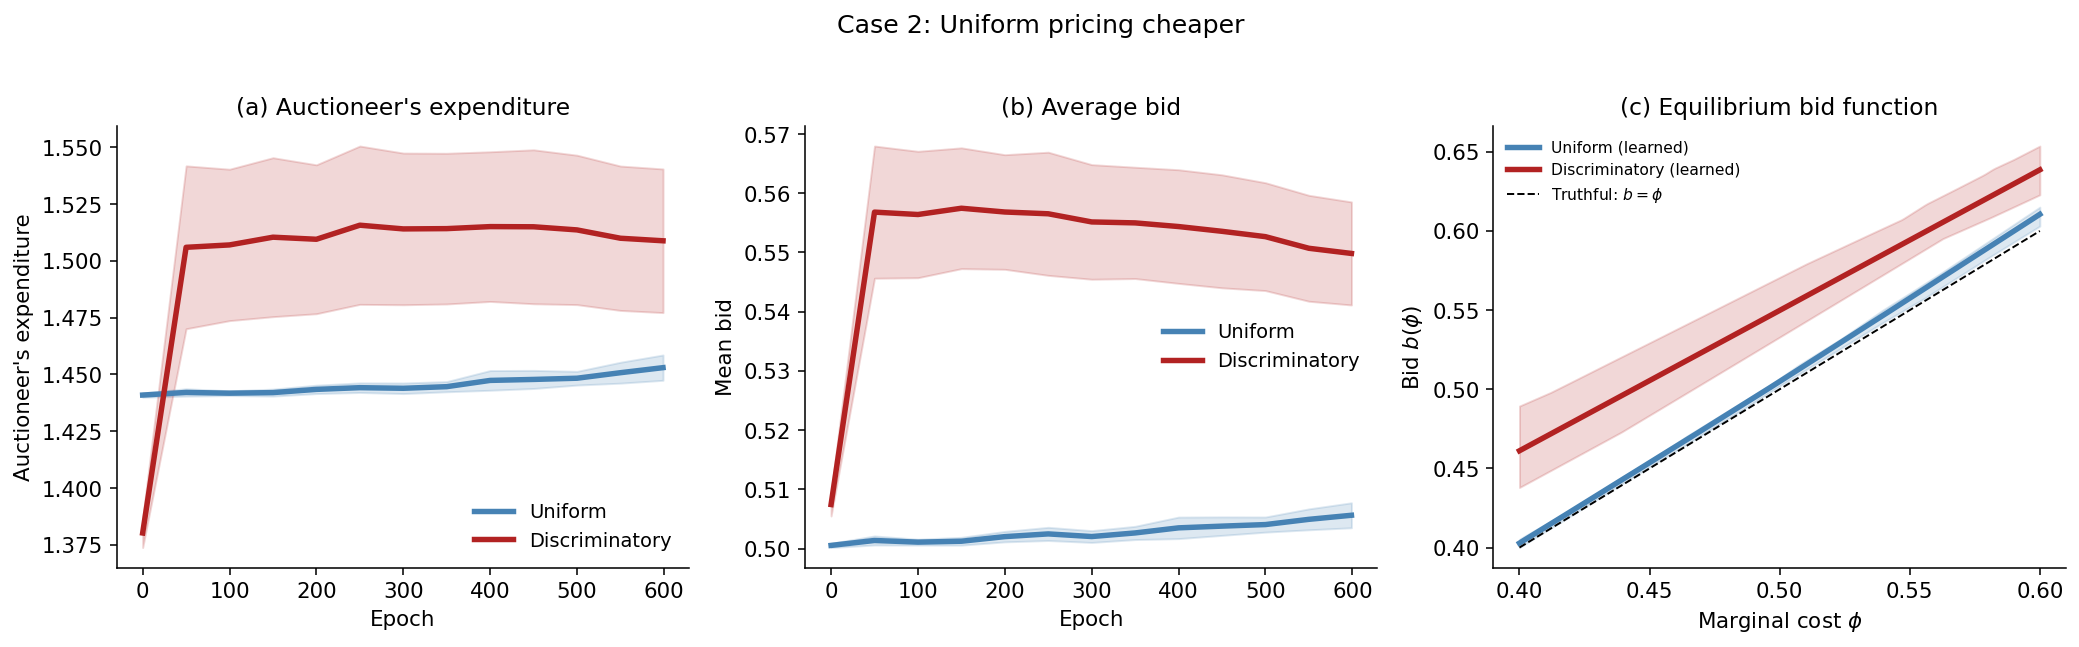

In [31]:
plot_with_bne(
        res_u2, res_p2,
        title_prefix="Case 2: Uniform pricing cheaper",
        show_bne=False,   # BNE formula is for U(0,1), not applicable here
        save_dir="simulationPABvsPACmultiunituniform"
    )